# Image Cleaning

## Imports

In [1]:
import os
from pathlib import Path
import pypff
from matplotlib import pyplot as plt
import numpy as np

In [2]:
def colorbar(mappable, label=None):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    if label is not None:
        cbar.set_label(label)
    plt.sca(last_axes)
    return cbar

# source: https://joseph-long.com/writing/colorbars/

## Read Test Data

In [3]:
base_dir = os.getcwd()
base_dir = Path(base_dir)
data_path = (base_dir.parent / "test_data" / "20251020" / "Gattini" / "pff").resolve()
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")
else:
    print(data_path)

/Users/nik/Documents/PANOSETI/PANOSETI-High-Energy-Analysis-Pipeline/test_data/20251020/Gattini/pff


In [4]:
# read ph1024 data file
file = str(data_path / "start_2025-10-20T06:50:55Z.dp_ph1024.bpp_2.module_254.seqno_0.pff")
pff = pypff.io.datapff(file)
data, metadata = pff.readpff(metadata=True)

## Threshold Cleaning

Let's start by plotting a "random" image (event 4321)

In [5]:
event = data[4321].reshape(32,32)

Text(0.5, 1.0, 'Raw Image')

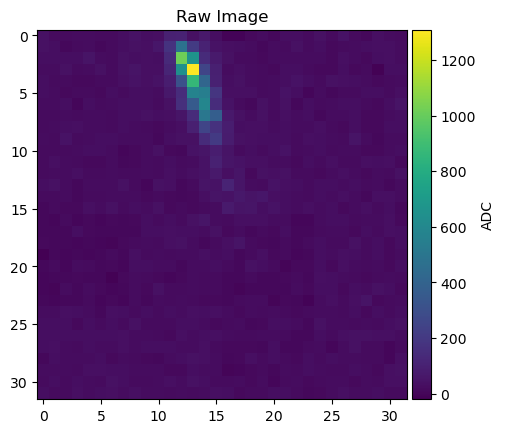

In [6]:
fig = plt.figure()
image = plt.imshow(event, aspect="equal")
colorbar(image, "ADC")
plt.title("Raw Image")

Now we need to import the cleaning functions

In [7]:
from heap.image_cleaning import threshold_clean

Pedvars are not implemented yet, so we will make a random distribution

In [8]:
np.random.seed(20251020)
pedvars = np.random.normal(16, 1, size=event.shape)

Text(0.5, 1.0, 'Faux Pedestal Variance Map')

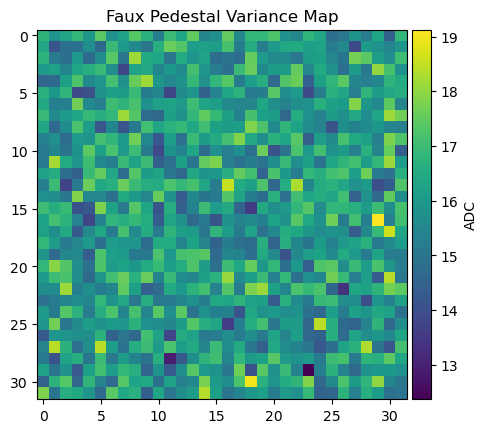

In [9]:
fig = plt.figure()
image=plt.imshow(pedvars, aspect="equal")
colorbar(image, "ADC")
plt.title("Faux Pedestal Variance Map")

Now let's do a simple example of image cleaning

In [10]:
cleaned_event, mask = threshold_clean(event, pedvars)

`threshold_clean()` returns the cleaned image, and a mask of the removed pixels. The mask is just a binary mapping. Here's what that looks like:

Text(0.5, 1.0, 'Removed Pixels')

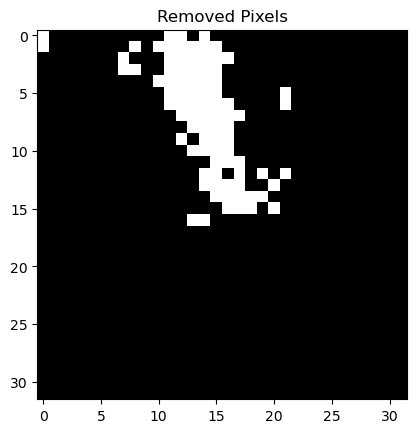

In [11]:
fig = plt.figure()
image=plt.imshow(mask, aspect="equal",cmap='binary_r')
plt.title("Removed Pixels")

And here is the final, cleaned image:

Text(0.5, 1.0, 'Cleaned Image')

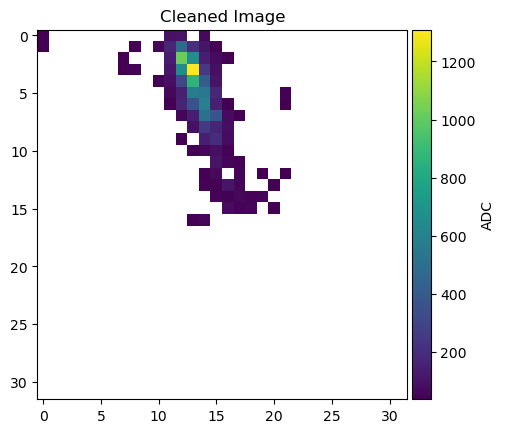

In [12]:
fig = plt.figure()
image=plt.imshow(cleaned_event, aspect="equal")
colorbar(image, "ADC")
plt.title("Cleaned Image")

Here's a comparison between the original image and the cleaned image:

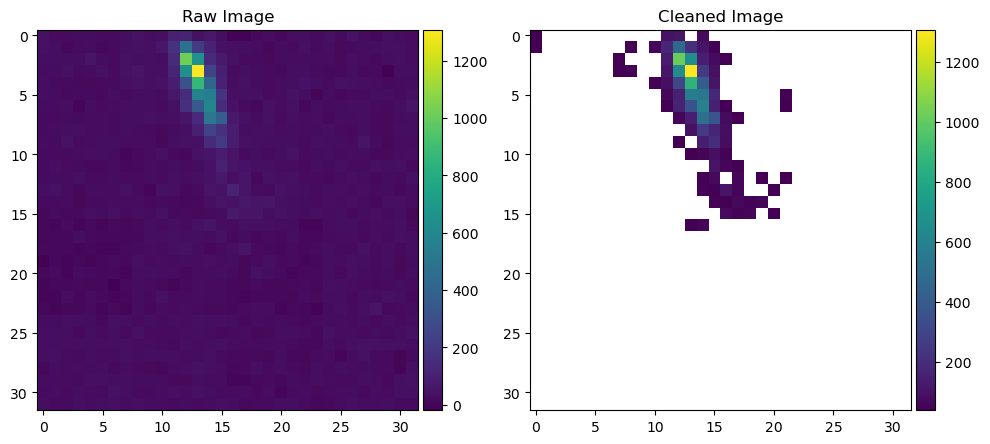

In [13]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event, aspect="equal")
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event, aspect="equal")
colorbar(image2)
ax2.set_title("Cleaned Image")

fig.tight_layout(h_pad=2)

By default, the image pixel threshold is 2.5 and the border pixel threshold is 5.0. These are in units of the pedestal variance.

We can change this in the function call of `threshold_clean()` like so:

In [14]:
cleaned_event_raised_thresh, mask_raised_thresh = threshold_clean(event, pedvars, border_threshold=3.5, image_threshold=7.0)

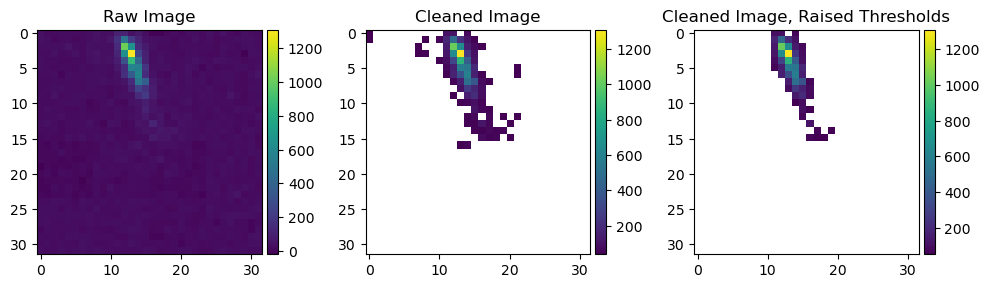

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event, aspect="equal")
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event, aspect="equal")
colorbar(image2)
ax2.set_title("Cleaned Image")

# plot the cleaned image with raised cleaning thresholds
image3 = ax3.imshow(cleaned_event_raised_thresh, aspect="equal")
colorbar(image3)
ax3.set_title("Cleaned Image, Raised Thresholds")

fig.tight_layout(h_pad=2)

Here's another example of threshold cleaning (with default thresholds) on a smaller event.

In [16]:
event2 = data[10].reshape(32,32)

In [17]:
pedvars2 = np.random.normal(16, 1, size=event2.shape)

In [18]:
cleaned_event2, mask2 = threshold_clean(event2, pedvars2)

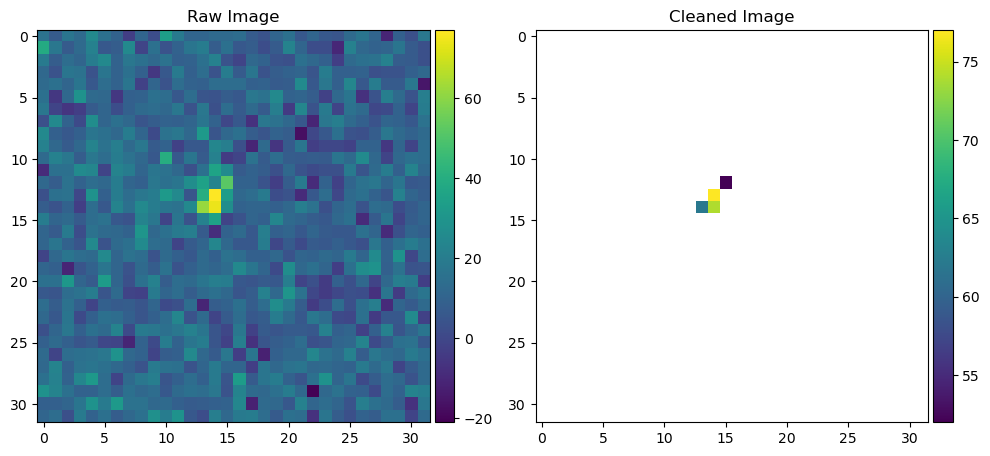

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event2, aspect="equal")
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event2, aspect="equal")
colorbar(image2)
ax2.set_title("Cleaned Image")

fig.tight_layout(h_pad=2)